keeps the original advanced model structure and training pipeline, but replaces the way to get negatives.

In [23]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()


In [10]:
import random
import re
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Sequence

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import BertTokenizer, BertModel, ViTModel, ViTImageProcessor

from tqdm import tqdm

In [11]:
TRAIN_SUBSET_SIZE = None  # Set to None for full training set
VAL_SUBSET_SIZE = None
INCLUDE_RANDOM_NEGATIVE = False
MAX_TEXT_LEN = 32

In [12]:
dataset = load_dataset("Zoe3324/flickr30k-pairs")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]

if TRAIN_SUBSET_SIZE is not None:
    train_data = train_data.select(range(min(TRAIN_SUBSET_SIZE, len(train_data))))
if VAL_SUBSET_SIZE is not None:
    val_data = val_data.select(range(min(VAL_SUBSET_SIZE, len(val_data))))

for i in range(5):
    print(train_data[2 * i])

README.md:   0%|          | 0.00/657 [00:00<?, ?B/s]

data/train-00000-of-00012.parquet:   0%|          | 0.00/97.0M [00:00<?, ?B/s]

data/train-00001-of-00012.parquet:   0%|          | 0.00/96.2M [00:00<?, ?B/s]

data/train-00002-of-00012.parquet:   0%|          | 0.00/101M [00:00<?, ?B/s]

data/train-00003-of-00012.parquet:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/145000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5070 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x792A3C5871D0>, 'caption': 'Two young guys with shaggy hair look at their hands while hanging out in the yard.', 'split': 'train', 'img_id': '0', 'filename': '1000092795.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x792A3C62CBC0>, 'caption': 'Two men in green shirts are standing in a yard.', 'split': 'train', 'img_id': '0', 'filename': '1000092795.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500 at 0x792A3C62F530>, 'caption': 'Two friends enjoy time spent together.', 'split': 'train', 'img_id': '0', 'filename': '1000092795.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x792A3C62D2B0>, 'caption': 'Workers look down from up above on a piece of equipment.', 'split': 'train', 'img_id': '1', 'filename': '10002456.jpg'}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x374 at 0x792A3C62EC00>, 'c

In [13]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [14]:
OUTPUT_DIR = Path("/content/advanced_hard_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/content/advanced_hard_outputs')

In [28]:
_TOKEN_RE = re.compile(r"\\w+")


def _simple_tokens(text: str) -> set[str]:
    return set(_TOKEN_RE.findall(text.lower()))


def _jaccard_overlap(a: set[str], b: set[str]) -> float:
    if not a or not b:
        return 0.0
    union = a | b
    if not union:
        return 0.0
    return len(a & b) / len(union)


@dataclass
class AdvancedHardNegativeCollator:
    tokenizer: Any
    image_processor: Any
    max_length: int = 32
    include_random_negative: bool = False
    random_seed: int = 42

    def __post_init__(self):
        self.rng = random.Random(self.random_seed)

    def _pick_hard_negative_index(
        self,
        anchor_idx: int,
        texts: Sequence[str],
        img_ids: Sequence[Any],
        token_sets: Sequence[set[str]],
    ) -> int:
        anchor_group = img_ids[anchor_idx]
        candidates = [j for j in range(len(texts)) if img_ids[j] != anchor_group]
        if not candidates:
            return anchor_idx

        anchor_tokens = token_sets[anchor_idx]
        scored = [
            (_jaccard_overlap(anchor_tokens, token_sets[j]), j)
            for j in candidates
        ]
        scored.sort(key=lambda x: (x[0], self.rng.random()), reverse=True)
        return scored[0][1]

    def _pick_random_negative_index(
        self,
        anchor_idx: int,
        img_ids: Sequence[Any],
        exclude_idx: int,
    ) -> int:
        anchor_group = img_ids[anchor_idx]
        candidates = [
            j for j in range(len(img_ids))
            if img_ids[j] != anchor_group and j != exclude_idx
        ]
        if not candidates:
            return exclude_idx
        return self.rng.choice(candidates)

    def __call__(self, batch: Iterable[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch = list(batch)
        texts = [x["caption"] for x in batch]
        images = [x["image"].convert("RGB") for x in batch]
        img_ids = [x.get("img_id", idx) for idx, x in enumerate(batch)]

        token_sets = [_simple_tokens(text) for text in texts]

        all_texts: List[str] = []
        all_images: List[Any] = []
        labels: List[float] = []

        all_texts.extend(texts)
        all_images.extend(images)
        labels.extend([1.0] * len(texts))

        hard_negative_indices = []
        for i in range(len(texts)):
            neg_idx = self._pick_hard_negative_index(i, texts, img_ids, token_sets)
            hard_negative_indices.append(neg_idx)
            all_texts.append(texts[neg_idx])
            all_images.append(images[i])
            labels.append(0.0)

        if self.include_random_negative:
            for i in range(len(texts)):
                neg_idx = self._pick_random_negative_index(i, img_ids, hard_negative_indices[i])
                all_texts.append(texts[neg_idx])
                all_images.append(images[i])
                labels.append(0.0)

        text_enc = tokenizer(
            all_texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        image_enc = image_processor(
            images=all_images,
            return_tensors="pt"
        )

        return {
            "input_ids": text_enc["input_ids"],
            "attention_mask": text_enc["attention_mask"],
            "pixel_values": image_enc["pixel_values"],
            "labels": torch.tensor(labels, dtype=torch.float32),
        }


hard_negative_collate_fn = AdvancedHardNegativeCollator(
    tokenizer=tokenizer,
    image_processor=image_processor,
    max_length=MAX_TEXT_LEN,
    include_random_negative=INCLUDE_RANDOM_NEGATIVE,
    random_seed=42,
)

In [15]:
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, q, k, v):
        Q = self.query(q)
        K = self.key(k)
        V = self.value(v)

        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn = torch.softmax(attn, dim=-1)
        out = torch.matmul(attn, V)
        return out

In [16]:
class MultiModalModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.text_encoder = BertModel.from_pretrained("bert-base-uncased")
        self.image_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")

        dim = 768
        self.cross_attn = CrossAttention(dim)

        self.match_head = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        image_out = self.image_encoder(
            pixel_values=pixel_values
        ).last_hidden_state

        fused = self.cross_attn(text_out, image_out, image_out)
        fused = fused.mean(dim=1)
        logits = self.match_head(fused).squeeze(-1)
        return logits

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = MultiModalModel().to(device)

cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
def train(model, batch_size=32, epochs=5, lr=3e-5):
    train_loader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=hard_negative_collate_fn,
        num_workers=4,
    )
    val_loader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=hard_negative_collate_fn,
        num_workers=4,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    best_val_acc = -1.0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        model.eval()
        total_val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                pixel_values = batch["pixel_values"].to(device)
                labels = batch["labels"].to(device)

                logits = model(input_ids, attention_mask, pixel_values)
                loss = criterion(logits, labels)
                total_val_loss += loss.item()

                preds = (torch.sigmoid(logits) > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = correct / total
        epoch_log = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
        }
        history.append(epoch_log)

        print(epoch_log)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            checkpoint = {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "val_acc": val_acc,
                "config": {
                    "batch_size": batch_size,
                    "epochs": epochs,
                    "lr": lr,
                    "max_length": MAX_TEXT_LEN,
                    "hard_negative": True,
                    "include_random_negative": INCLUDE_RANDOM_NEGATIVE,
                    "train_subset_size": TRAIN_SUBSET_SIZE,
                },
            }
            torch.save(checkpoint, OUTPUT_DIR / "best_advanced_hard.pt")
            print("saved best checkpoint to", OUTPUT_DIR / "best_advanced_hard.pt")

    return history

In [34]:
BATCH_SIZE = 32
NUM_EPOCHS = 2
LR = 3e-5

history = train(model, batch_size=BATCH_SIZE, epochs=NUM_EPOCHS, lr=LR)
history

Epoch 1/2 [Val]: 100%|██████████| 159/159 [00:28<00:00,  5.54it/s]


{'epoch': 1, 'train_loss': 0.16695927029980276, 'val_loss': 0.19365800974550862, 'val_acc': 0.9298816568047338}
saved best checkpoint to /content/advanced_hard_outputs/best_advanced_hard.pt


Epoch 2/2 [Val]: 100%|██████████| 159/159 [00:28<00:00,  5.54it/s]


{'epoch': 2, 'train_loss': 0.10230790686856098, 'val_loss': 0.19066602370625585, 'val_acc': 0.934516765285996}
saved best checkpoint to /content/advanced_hard_outputs/best_advanced_hard.pt


[{'epoch': 1,
  'train_loss': 0.16695927029980276,
  'val_loss': 0.19365800974550862,
  'val_acc': 0.9298816568047338},
 {'epoch': 2,
  'train_loss': 0.10230790686856098,
  'val_loss': 0.19066602370625585,
  'val_acc': 0.934516765285996}]

In [ ]:
# checkpoint = torch.load(OUTPUT_DIR / "best_advanced_hard.pt", weights_only=False)
# model.load_state_dict(checkpoint["model_state_dict"])

In [35]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
val_acc = [h["val_acc"] for h in history]

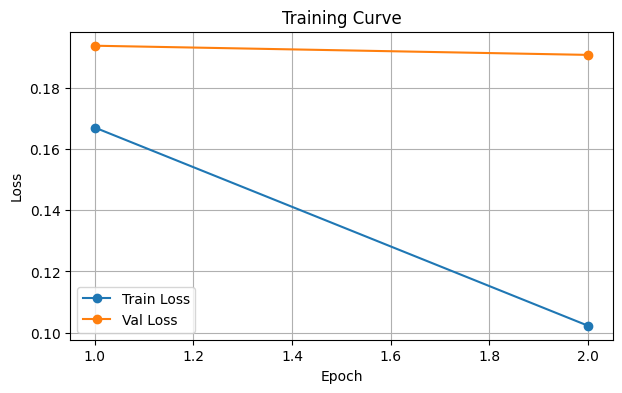

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, marker="o", label="Train Loss")
plt.plot(epochs, val_loss, marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

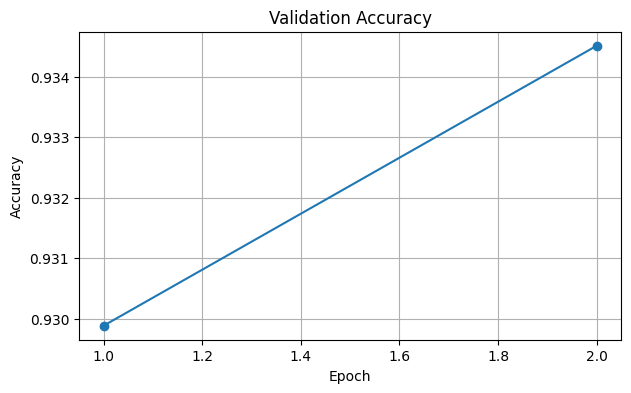

In [37]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_acc, marker="o")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Upload Best Checkpoint to Hugging Face

In [18]:
!pip install -q huggingface_hub

In [19]:
from huggingface_hub import HfApi, login

login()

In [ ]:
repo_id = "Zoe3324/flickr30k-advanced"
api = HfApi()

hf_model_tag = (
    f"hardneg_bs{BATCH_SIZE}_"
    f"lr{LR}_"
    f"epoch{NUM_EPOCHS}_fulldata"
)
hf_filename = f"best_advanced_{hf_model_tag}.pt"

api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)
api.upload_file(
    path_or_fileobj=str(OUTPUT_DIR / "best_advanced_hard.pt"),
    path_in_repo=hf_filename,
    repo_id=repo_id,
    repo_type="model",
)

print(f"uploaded to {repo_id}/{hf_filename}")

In [23]:
def eval_collate_fn(batch):
    texts = [x["caption"] for x in batch]
    images = [x["image"].convert("RGB") for x in batch]
    return texts, images


def evaluate_retrieval(model, data, num_samples=200):
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_fn)

    all_texts = []
    all_images = []
    for texts, images in loader:
        all_texts.extend(texts)
        all_images.extend(images)

    N = len(all_texts)
    score_matrix = torch.zeros(N, N)

    model.eval()
    with torch.no_grad():
        for i in tqdm(range(N), desc="Scoring pairs"):
            img = all_images[i]
            image_enc = image_processor(images=[img] * N, return_tensors="pt")
            text_enc = tokenizer(
                all_texts,
                padding="max_length",
                truncation=True,
                max_length=32,
                return_tensors="pt"
            )

            pixel_values = image_enc["pixel_values"].to(device)
            input_ids = text_enc["input_ids"].to(device)
            attention_mask = text_enc["attention_mask"].to(device)

            scores = []
            bs = 64
            for start in range(0, N, bs):
                end = min(start + bs, N)
                logits = model(input_ids[start:end], attention_mask[start:end], pixel_values[start:end])
                scores.append(torch.sigmoid(logits).cpu())

            score_matrix[i] = torch.cat(scores)

    def recall_at_k(score_mat, k):
        correct = 0
        for i in range(score_mat.size(0)):
            topk = score_mat[i].topk(k).indices
            if i in topk:
                correct += 1
        return correct / score_mat.size(0)

    print()
    print(f"=== Image-to-Text Retrieval (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix, 1):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix, 5):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix, 10):.4f}")

    score_matrix_t = score_matrix.T
    print(f"=== Text-to-Image Retrieval (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix_t, 1):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix_t, 5):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix_t, 10):.4f}")

In [24]:
def eval_collate_grouped(batch):
    texts = [x["caption"] for x in batch]
    images = [x["image"].convert("RGB") for x in batch]
    img_ids = [x["img_id"] for x in batch]
    return texts, images, img_ids


def evaluate_retrieval_grouped(model, data, num_samples=200):
    subset = data.select(range(min(num_samples, len(data))))
    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=eval_collate_grouped)

    all_texts = []
    all_images = []
    all_img_ids = []
    for texts, images, img_ids in loader:
        all_texts.extend(texts)
        all_images.extend(images)
        all_img_ids.extend(img_ids)

    group_to_indices = {}
    for idx, gid in enumerate(all_img_ids):
        if gid not in group_to_indices:
            group_to_indices[gid] = []
        group_to_indices[gid].append(idx)

    N = len(all_texts)
    score_matrix = torch.zeros(N, N)

    model.eval()
    with torch.no_grad():
        for i in tqdm(range(N), desc="Scoring grouped pairs"):
            img = all_images[i]
            image_enc = image_processor(images=[img] * N, return_tensors="pt")
            text_enc = tokenizer(
                all_texts,
                padding="max_length",
                truncation=True,
                max_length=32,
                return_tensors="pt"
            )

            pixel_values = image_enc["pixel_values"].to(device)
            input_ids = text_enc["input_ids"].to(device)
            attention_mask = text_enc["attention_mask"].to(device)

            scores = []
            bs = 64
            for start in range(0, N, bs):
                end = min(start + bs, N)
                logits = model(input_ids[start:end], attention_mask[start:end], pixel_values[start:end])
                scores.append(torch.sigmoid(logits).cpu())

            score_matrix[i] = torch.cat(scores)

    def recall_at_k(score_mat, k, query_ids, mapping):
        correct = 0
        for i in range(score_mat.size(0)):
            topk = score_mat[i].topk(k).indices.tolist()
            correct_indices = set(mapping[query_ids[i]])
            if any(idx in correct_indices for idx in topk):
                correct += 1
        return correct / score_mat.size(0)

    print()
    print(f"=== Grouped Image-to-Text Retrieval (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix, 1, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix, 5, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix, 10, all_img_ids, group_to_indices):.4f}")

    score_matrix_t = score_matrix.T
    print(f"=== Grouped Text-to-Image Retrieval (N={N}) ===")
    print(f"  Recall@1:  {recall_at_k(score_matrix_t, 1, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@5:  {recall_at_k(score_matrix_t, 5, all_img_ids, group_to_indices):.4f}")
    print(f"  Recall@10: {recall_at_k(score_matrix_t, 10, all_img_ids, group_to_indices):.4f}")

In [1]:
from huggingface_hub import hf_hub_download
import torch


In [4]:
BATCH_SIZE = 32
NUM_EPOCHS = 2
LR = 3e-5

In [5]:
repo_id = "Zoe3324/flickr30k-advanced"
hf_model_tag = (
    f"hardneg_bs{BATCH_SIZE}_"
    f"lr{LR}_"
    f"epoch{NUM_EPOCHS}_fulldata"
)
filename = f"best_advanced_{hf_model_tag}.pt"

ckpt_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    repo_type="model",
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


best_advanced_hardneg_bs32_lr3e-05_epoch(…):   0%|          | 0.00/792M [00:00<?, ?B/s]

In [21]:
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()


MultiModalModel(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, eleme

In [25]:
evaluate_retrieval(model, test_data, num_samples=200)
evaluate_retrieval_grouped(model, test_data, num_samples=200)

Scoring pairs: 100%|██████████| 200/200 [04:23<00:00,  1.32s/it]



=== Image-to-Text Retrieval (N=200) ===
  Recall@1:  0.1800
  Recall@5:  0.7700
  Recall@10: 0.9200
=== Text-to-Image Retrieval (N=200) ===
  Recall@1:  0.1650
  Recall@5:  0.7500
  Recall@10: 0.9400


Scoring grouped pairs: 100%|██████████| 200/200 [04:21<00:00,  1.31s/it]


=== Grouped Image-to-Text Retrieval (N=200) ===
  Recall@1:  0.9000
  Recall@5:  1.0000
  Recall@10: 1.0000
=== Grouped Text-to-Image Retrieval (N=200) ===
  Recall@1:  0.7500
  Recall@5:  0.7500
  Recall@10: 0.9400
